## tune-weights.ipynb

Finds optimal block weights for V2 and V3 without refitting a KNN model
for every combination.

### Why the naive approach is slow
The original approach rebuilt and refitted a full NearestNeighbors model
for every weight combination — that is O(n_albums × n_features) per trial
and took ~40 minutes for 36 combinations.

### Fast approach: weighted query-time dot product
After L2 normalisation, cosine similarity is just a dot product. Instead
of rebuilding the model, we:

1. Normalise each feature block **independently** once (stored as dense float32)
2. At query time, combine blocks with trial weights, re-normalise the
   **query vector only** (one row, near-instant), then compute dot products
   against the pre-stored full matrix
3. Take the top-N results

This reduces each trial from ~60s to ~0.1s — the full 36-combo V2 grid
runs in under a minute.

### Strategy
| Model | Free weights | Approach |
|---|---|---|
| V2 | `W_COUNTRY`, `W_TRACK_STATS` | Grid search 6×6 = 36 combos |
| V3 | V2 weights fixed + `W_ROLE_FAMILY`, `W_INSTRUMENT`, `W_CONTRIB_CNT` | Random search 80 samples |

In [1]:
import pickle
import itertools
import random
import time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.sparse import csr_matrix, hstack, load_npz
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

DATA_DIR     = '../data'
FEATURES_DIR = f'{DATA_DIR}/features'
N_RESULTS    = 10
RANDOM_SEED  = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [2]:
# ── Ground truth ──────────────────────────────────────────────────────────
# Load the scope-filtered ground truth built in evaluate-lastfm.ipynb.
# If running standalone, rebuild it here.

try:
    # Reuse from memory if evaluate-lastfm.ipynb ran in the same kernel
    _ = ground_truth
    _ = mb_lookup
    print(f'Ground truth in memory: {len(ground_truth):,} seed albums')
except NameError:
    # Rebuild from scratch
    try:
        lastfm = pd.read_parquet(f'{DATA_DIR}/lastfm_similar_albums.parquet')
    except Exception:
        lastfm = pd.read_csv(f'{DATA_DIR}/lastfm_similar_albums.csv')

    lastfm.columns = lastfm.columns.str.strip()
    for col in ['album','artist','similar_album','similar_artist']:
        lastfm[col + '_key'] = lastfm[col].str.lower().str.strip()

    mb_lookup = (
        pd.read_parquet(f'{DATA_DIR}/mb_album_artists.parquet',
                        columns=['album_id','album_name','artist_name'])
        .drop_duplicates(subset='album_id')
    )
    mb_lookup['album_key']  = mb_lookup['album_name'].str.lower().str.strip()
    mb_lookup['artist_key'] = mb_lookup['artist_name'].str.lower().str.strip()
    mb_index = mb_lookup.set_index(['album_key','artist_key'])['album_id']

    seed_pairs = lastfm[['album_key','artist_key']].drop_duplicates()
    seed_pairs = seed_pairs.join(mb_index.rename('seed_mb_id'),
                                  on=['album_key','artist_key'], how='left')
    lastfm = lastfm.join(mb_index.rename('similar_mb_id'),
                          on=['similar_album_key','similar_artist_key'], how='left')
    lastfm = lastfm.merge(seed_pairs, on=['album_key','artist_key'], how='left')

    # Load all model ids to define studio-album universe
    ids_v1 = np.load(f'{DATA_DIR}/model/album_ids_annotated.npy',       allow_pickle=True)
    ids_v2 = np.load(f'{DATA_DIR}/model_v2/album_ids_annotated_v2.npy', allow_pickle=True)
    ids_v3 = np.load(f'{DATA_DIR}/model_v3/album_ids_annotated_v3.npy', allow_pickle=True)
    all_model_ids = set(ids_v1) | set(ids_v2) | set(ids_v3)

    gt_filtered = (
        lastfm
        .dropna(subset=['seed_mb_id','similar_mb_id'])
        .pipe(lambda df: df[df['similar_mb_id'].isin(all_model_ids)])
    )
    ground_truth = (
        gt_filtered
        .groupby('seed_mb_id')['similar_mb_id']
        .apply(set)
        .to_dict()
    )
    print(f'Ground truth rebuilt: {len(ground_truth):,} seed albums')

# Normalise all IDs to plain Python int so set intersections work
# regardless of whether source was float, int32, int64, numpy scalar etc.
ground_truth = {
    int(k): {int(v) for v in vs}
    for k, vs in ground_truth.items()
}

# Also normalise ann_ids and rebuild id2row_ann with int keys
# (done here so it's consistent for both evaluate-lastfm and tune-weights)
print(f'Ground truth normalised: {len(ground_truth):,} seed albums (all IDs cast to int)')


Ground truth rebuilt: 2,401 seed albums
Ground truth normalised: 2,401 seed albums (all IDs cast to int)


In [3]:
# ── Feature blocks (loaded once, reused across all weight combinations) ───
with open(f'{FEATURES_DIR}/album_ids.pkl', 'rb') as f:
    album_id_order = pickle.load(f)

X_tags        = load_npz(f'{FEATURES_DIR}/album_tags_matrix.npz')
X_labels      = load_npz(f'{FEATURES_DIR}/album_labels_matrix.npz')
X_types       = load_npz(f'{FEATURES_DIR}/album_types_matrix.npz')
X_ratings     = load_npz(f'{FEATURES_DIR}/album_ratings_matrix.npz')
X_country     = load_npz(f'{FEATURES_DIR}/album_country_matrix.npz')
X_track_stats = load_npz(f'{FEATURES_DIR}/album_track_stats_matrix.npz')
X_role_family = load_npz(f'{FEATURES_DIR}/album_role_family_matrix.npz')
X_instrument  = load_npz(f'{FEATURES_DIR}/album_instrument_matrix.npz')
X_contrib_cnt = load_npz(f'{FEATURES_DIR}/album_contributor_counts_matrix.npz')

# Expand all blocks to full album universe (same logic as knn-v2/v3)
full_album_ids = pd.Index(
    pd.read_parquet(f'{DATA_DIR}/mb_album.parquet', columns=['id'])['id'].sort_values()
)

def _expand(X, row_pos, n):
    coo = X.tocoo()
    return csr_matrix((coo.data, (row_pos[coo.row], coo.col)), shape=(n, X.shape[1]))

if len(album_id_order) < len(full_album_ids):
    pos   = full_album_ids.get_indexer(album_id_order)
    n_full = len(full_album_ids)
    X_tags        = _expand(X_tags,        pos, n_full)
    X_labels      = _expand(X_labels,      pos, n_full)
    X_types       = _expand(X_types,       pos, n_full)
    X_ratings     = _expand(X_ratings,     pos, n_full)
    X_country     = _expand(X_country,     pos, n_full)
    X_track_stats = _expand(X_track_stats, pos, n_full)
    X_role_family = _expand(X_role_family, pos, n_full)
    X_instrument  = _expand(X_instrument,  pos, n_full)
    X_contrib_cnt = _expand(X_contrib_cnt, pos, n_full)
    album_id_order = full_album_ids.tolist()

print('Feature blocks ready.')
print(f'Full album universe: {len(album_id_order):,}')

Feature blocks ready.
Full album universe: 2,241,402


In [4]:
import time

X_base_full  = hstack([X_tags, X_labels, X_types, X_ratings]).tocsr()
row_lengths  = np.diff(X_base_full.indptr)
has_feat     = row_lengths > 0
ann_ids      = np.array(album_id_order)[has_feat]
id2row_ann   = {int(aid): i for i, aid in enumerate(ann_ids)}
n_ann        = int(has_feat.sum())
all_model_ids = set(int(x) for x in ann_ids)
print(f'Annotated albums: {n_ann:,}')

def _clean(X):
    M = X[has_feat].tocsr().astype(np.float32)
    np.nan_to_num(M.data, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    M.eliminate_zeros()
    return M

BLK = {
    'tags':        _clean(X_tags),
    'labels':      _clean(X_labels),
    'types':       _clean(X_types),
    'ratings':     _clean(X_ratings),
    'country':     _clean(X_country),
    'track_stats': _clean(X_track_stats),
    'role_family': _clean(X_role_family),
    'instrument':  _clean(X_instrument),
    'contrib_cnt': _clean(X_contrib_cnt),
}
BLK_ROW_SQ = {
    k: np.asarray(M.power(2).sum(axis=1)).ravel().astype(np.float32)
    for k, M in BLK.items()
}

# Scope-filter ground truth
ground_truth_scoped = {
    int(k): {int(v) for v in vs if int(v) in all_model_ids}
    for k, vs in ground_truth.items()
}
ground_truth_scoped = {k: vs for k, vs in ground_truth_scoped.items() if vs}
seed_ids   = [s for s in ground_truth_scoped if s in id2row_ann]
seed_rows  = np.array([id2row_ann[s] for s in seed_ids], dtype=np.int32)
seed_known = [ground_truth_scoped[s] for s in seed_ids]
n_seeds    = len(seed_ids)
print(f'Seeds in model index: {n_seeds:,}')

# ── Pre-compute dot products, stored as float16 ───────────────────────────
# float16: 2 bytes/value  →  n_seeds × n_ann × 2 = 1,997 × 1,008,102 × 2 ≈ 4 GB/block
# 6 V2 blocks × 4 GB = 24 GB  — tight but feasible on 32 GB with sparse blocks freed
# After storing SEED_DOTS, free BLK to recover ~2 GB of sparse storage

def precompute_dots(block_names):
    dots, norms = {}, {}
    t0 = time.time()
    for k in block_names:
        M  = BLK[k]
        Q  = M[seed_rows]                              # sparse (n_seeds × ncols)
        D  = M.dot(Q.T).toarray().T.astype(np.float16) # (n_seeds × n_ann) float16
        dots[k]  = np.ascontiguousarray(D)
        norms[k] = BLK_ROW_SQ[k][seed_rows].astype(np.float32)
        print(f'  {k:<14} {str(D.shape):<22} {D.nbytes/1e9:.2f} GB  ({time.time()-t0:.0f}s)')
    return dots, norms

# Compute V2 blocks; free sparse BLK entries afterwards to reclaim RAM
V2_BLOCKS = ['tags','labels','types','ratings','country','track_stats']
print(f'Pre-computing {len(V2_BLOCKS)} blocks as float16...')
SEED_DOTS, SEED_NORMS_SQ = precompute_dots(V2_BLOCKS)

# Free sparse blocks no longer needed to recover memory for evaluate_weights
for k in list(BLK.keys()):
    del BLK[k]
import gc; gc.collect()
print('Sparse BLK freed. Ready for V1/V2 evaluation.')
print('To run V3 searches, reload sparse blocks and call precompute_dots for V3 extras.')

Annotated albums: 1,008,102
Seeds in model index: 1,974
Pre-computing 6 blocks as float16...
  tags           (1974, 1008102)        3.98 GB  (35s)
  labels         (1974, 1008102)        3.98 GB  (62s)
  types          (1974, 1008102)        3.98 GB  (91s)
  ratings        (1974, 1008102)        3.98 GB  (120s)
  country        (1974, 1008102)        3.98 GB  (151s)
  track_stats    (1974, 1008102)        3.98 GB  (236s)
Sparse BLK freed. Ready for V1/V2 evaluation.
To run V3 searches, reload sparse blocks and call precompute_dots for V3 extras.


In [5]:
# CHUNK_SIZE controls peak memory and speed:
# 50_000 cols × 1997 seeds × 4 bytes = ~400 MB per chunk
# Larger = fewer passes over SEED_DOTS = faster; smaller = less RAM
CHUNK_SIZE = 50_000
K_TOP      = 30   # candidates kept per seed before final filter

def evaluate_weights(weights: dict, n: int = 10) -> dict:
    BLOCK_KEYS = [
        ('tags',        weights.get('W_TAGS',        1.0)),
        ('labels',      weights.get('W_LABELS',      1.0)),
        ('types',       weights.get('W_TYPES',       1.0)),
        ('ratings',     weights.get('W_RATINGS',     1.0)),
        ('country',     weights.get('W_COUNTRY',     0.0)),
        ('track_stats', weights.get('W_TRACK_STATS', 0.0)),
        ('role_family', weights.get('W_ROLE_FAMILY', 0.0)),
        ('instrument',  weights.get('W_INSTRUMENT',  0.0)),
        ('contrib_cnt', weights.get('W_CONTRIB_CNT', 0.0)),
    ]
    active = [(k, w) for k, w in BLOCK_KEYS if w != 0.0]
    w2     = {k: np.float32(w**2) for k, w in active}

    # Norms — cheap, (n_ann,) and (n_seeds,)
    cand_norm_sq = np.zeros(n_ann, dtype=np.float32)
    q_norm_sq    = np.zeros(n_seeds, dtype=np.float32)
    for k, _ in active:
        cand_norm_sq += w2[k] * BLK_ROW_SQ[k]
        q_norm_sq    += w2[k] * SEED_NORMS_SQ[k]
    cand_norms = np.sqrt(cand_norm_sq); cand_norms[cand_norms == 0] = 1.0
    q_norms    = np.sqrt(q_norm_sq);    q_norms[q_norms == 0]       = 1.0

    # Running top-K_TOP per seed: store best scores and their column indices
    best_scores = np.full((n_seeds, K_TOP), -np.inf, dtype=np.float32)
    best_cols   = np.zeros((n_seeds, K_TOP), dtype=np.int32)

    chunk_buf = np.empty((n_seeds, CHUNK_SIZE), dtype=np.float32)

    for col_start in range(0, n_ann, CHUNK_SIZE):
        col_end  = min(col_start + CHUNK_SIZE, n_ann)
        csize    = col_end - col_start
        chunk    = chunk_buf[:, :csize]
        chunk[:] = 0.0

        # Accumulate weighted dot products for this column slice
        for k, _ in active:
            # SEED_DOTS[k] is (n_seeds × n_ann) float16
            # slice columns → (n_seeds × csize), cast to float32, accumulate
            np.add(chunk,
                   SEED_DOTS[k][:, col_start:col_end].astype(np.float32) * w2[k],
                   out=chunk)

        # Cosine: divide by q_norms (seeds) and cand_norms (this slice)
        chunk /= q_norms[:, None]
        chunk /= cand_norms[None, col_start:col_end]

        # Mask self-similarities within this chunk
        self_mask = (seed_rows >= col_start) & (seed_rows < col_end)
        for s_idx in np.where(self_mask)[0]:
            chunk[s_idx, seed_rows[s_idx] - col_start] = -1.0

        # Merge chunk top-K into running best
        # Concatenate current best with chunk candidates
        if csize >= K_TOP:
            chunk_top_idx = np.argpartition(chunk, -K_TOP, axis=1)[:, -K_TOP:]
        else:
            chunk_top_idx = np.tile(np.arange(csize), (n_seeds, 1))
        chunk_top_scores = chunk[np.arange(n_seeds)[:, None], chunk_top_idx]
        chunk_top_cols   = (chunk_top_idx + col_start).astype(np.int32)

        combined_scores = np.concatenate([best_scores, chunk_top_scores], axis=1)
        combined_cols   = np.concatenate([best_cols,   chunk_top_cols],   axis=1)
        keep = np.argpartition(combined_scores, -K_TOP, axis=1)[:, -K_TOP:]
        best_scores = combined_scores[np.arange(n_seeds)[:, None], keep]
        best_cols   = combined_cols[  np.arange(n_seeds)[:, None], keep]

    # Sort final top-K_TOP descending
    order      = np.argsort(best_scores, axis=1)[:, ::-1]
    sorted_idx = best_cols[np.arange(n_seeds)[:, None], order]   # (n_seeds × K_TOP)

    # Score
    hits, precs, rrs = [], [], []
    for s_idx in range(n_seeds):
        known = seed_known[s_idx]
        s_id  = seed_ids[s_idx]
        recs  = [int(ann_ids[i]) for i in sorted_idx[s_idx]
                 if int(ann_ids[i]) != s_id][:n]
        overlap = set(recs) & known
        hits.append(1 if overlap else 0)
        precs.append(len(overlap) / n)
        rr = 0.0
        for rank, aid in enumerate(recs, 1):
            if aid in known: rr = 1.0 / rank; break
        rrs.append(rr)

    return {
        'hit_rate':  float(np.mean(hits)),
        'precision': float(np.mean(precs)),
        'mrr':       float(np.mean(rrs)),
        'n_eval':    len(hits),
    }


import time
n_chunks = (n_ann + CHUNK_SIZE - 1) // CHUNK_SIZE
print(f'CHUNK_SIZE={CHUNK_SIZE:,}  n_chunks={n_chunks}  '
      f'peak_mem≈{n_seeds * CHUNK_SIZE * 4 / 1e6:.0f} MB')
print('V1 baseline...')
t0 = time.time()
v1_scores = evaluate_weights({})
elapsed   = time.time() - t0
print(f'V1  hit={v1_scores["hit_rate"]:.4f}  prec={v1_scores["precision"]:.4f}  '
      f'mrr={v1_scores["mrr"]:.4f}  ({elapsed:.1f}s)')
print(f'Estimated V2 grid (36 combos): {36 * elapsed / 60:.1f} min')

CHUNK_SIZE=50,000  n_chunks=21  peak_mem≈395 MB
V1 baseline...
V1  hit=0.0643  prec=0.0072  mrr=0.0249  (71.4s)
Estimated V2 grid (36 combos): 42.9 min


In [6]:
GRID_COUNTRY     = [0.05, 0.1, 0.2, 0.35, 0.5, 1.0]
GRID_TRACK_STATS = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5]

v2_results = []
total = len(GRID_COUNTRY) * len(GRID_TRACK_STATS)
print(f'V2 grid search: {total} combinations...')
t0 = time.time()

for i, (wc, wt) in enumerate(itertools.product(GRID_COUNTRY, GRID_TRACK_STATS), 1):
    weights = {'W_COUNTRY': wc, 'W_TRACK_STATS': wt}
    scores  = evaluate_weights(weights)
    v2_results.append({**weights, **scores})
    if i % 6 == 0:
        best    = max(v2_results, key=lambda r: r['hit_rate'])
        elapsed = time.time() - t0
        eta     = elapsed / i * (total - i)
        print(f'  [{i}/{total}]  best: country={best["W_COUNTRY"]}  '
              f'track={best["W_TRACK_STATS"]}  hit={best["hit_rate"]:.4f}  '
              f'elapsed={elapsed:.0f}s  eta={eta:.0f}s')

v2_df   = pd.DataFrame(v2_results).sort_values('hit_rate', ascending=False)
v2_best = v2_df.iloc[0]
W_COUNTRY_FIXED     = float(v2_best['W_COUNTRY'])
W_TRACK_STATS_FIXED = float(v2_best['W_TRACK_STATS'])

print(f'\nTotal time: {time.time()-t0:.1f}s')
print(f'\n=== V2 best ===')
print(v2_df.head(10).to_string(index=False))

V2 grid search: 36 combinations...
  [6/36]  best: country=0.05  track=1.0  hit=0.0679  elapsed=376s  eta=1881s
  [12/36]  best: country=0.05  track=1.0  hit=0.0679  elapsed=751s  eta=1502s
  [18/36]  best: country=0.05  track=1.0  hit=0.0679  elapsed=1124s  eta=1124s
  [24/36]  best: country=0.35  track=0.25  hit=0.0694  elapsed=1501s  eta=751s
  [30/36]  best: country=0.35  track=0.25  hit=0.0694  elapsed=1874s  eta=375s
  [36/36]  best: country=0.35  track=0.25  hit=0.0694  elapsed=2248s  eta=0s

Total time: 2248.2s

=== V2 best ===
 W_COUNTRY  W_TRACK_STATS  hit_rate  precision      mrr  n_eval
      1.00           0.25  0.069402   0.007649 0.027892    1974
      1.00           0.75  0.069402   0.007649 0.028296    1974
      1.00           1.00  0.069402   0.007649 0.027958    1974
      0.35           0.25  0.069402   0.007700 0.027980    1974
      1.00           1.50  0.069402   0.007700 0.027960    1974
      1.00           0.50  0.069402   0.007649 0.027878    1974
      0.35

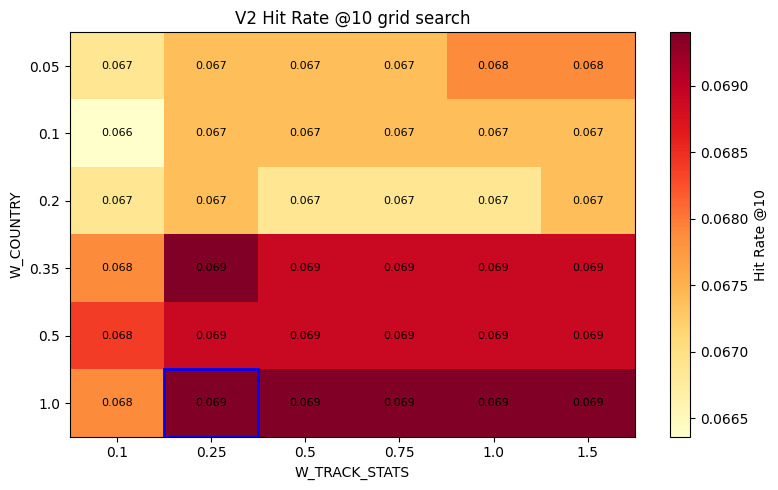

In [7]:
# Hit Rate heatmap for V2 grid
pivot = v2_df.pivot(index='W_COUNTRY', columns='W_TRACK_STATS', values='hit_rate')

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Hit Rate @10')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('W_TRACK_STATS')
ax.set_ylabel('W_COUNTRY')
ax.set_title('V2 Hit Rate @10 grid search')

# Annotate cells
for (r, c), val in np.ndenumerate(pivot.values):
    ax.text(c, r, f'{val:.3f}', ha='center', va='center', fontsize=8)

# Mark best cell
br = list(pivot.index).index(v2_best['W_COUNTRY'])
bc = list(pivot.columns).index(v2_best['W_TRACK_STATS'])
ax.add_patch(plt.Rectangle((bc-0.5, br-0.5), 1, 1, fill=False, edgecolor='blue', lw=2))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_v2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Only if BLK was cleared — rebuild V3 sparse blocks
def _clean(X):
    M = X[has_feat].tocsr().astype(np.float32)
    np.nan_to_num(M.data, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    M.eliminate_zeros()
    return M

BLK['role_family'] = _clean(X_role_family)
BLK['instrument']  = _clean(X_instrument)
BLK['contrib_cnt'] = _clean(X_contrib_cnt)

# Load V3 blocks into SEED_DOTS before searching
V3_EXTRA = ['role_family', 'instrument', 'contrib_cnt']
for k in V3_EXTRA:
    Q = BLK[k][seed_rows]
    SEED_DOTS[k]     = np.ascontiguousarray(BLK[k].dot(Q.T).toarray().T.astype(np.float16))
    SEED_NORMS_SQ[k] = BLK_ROW_SQ[k][seed_rows]
    print(f'  {k} loaded  {SEED_DOTS[k].shape}  {SEED_DOTS[k].nbytes/1e9:.2f} GB')

N_SAMPLES = 80

print(f'V3 random search: {N_SAMPLES} samples  '
      f'(W_COUNTRY={W_COUNTRY_FIXED}, W_TRACK_STATS={W_TRACK_STATS_FIXED} fixed)')
t0 = time.time()

V3_SPACE = {
    'W_ROLE_FAMILY':  (0.1, 2.0),
    'W_INSTRUMENT':   (0.1, 2.0),
    'W_CONTRIB_CNT':  (0.05, 1.0),
}

def log_uniform(lo, hi):
    return float(np.exp(np.random.uniform(np.log(lo), np.log(hi))))

v3_results = []
for i in range(1, N_SAMPLES + 1):
    sample = {
        'W_COUNTRY':     W_COUNTRY_FIXED,
        'W_TRACK_STATS': W_TRACK_STATS_FIXED,
        'W_ROLE_FAMILY': log_uniform(*V3_SPACE['W_ROLE_FAMILY']),
        'W_INSTRUMENT':  log_uniform(*V3_SPACE['W_INSTRUMENT']),
        'W_CONTRIB_CNT': log_uniform(*V3_SPACE['W_CONTRIB_CNT']),
    }
    scores = evaluate_weights(sample)
    v3_results.append({**sample, **scores})
    if i % 10 == 0:
        best    = max(v3_results, key=lambda r: r['hit_rate'])
        elapsed = time.time() - t0
        eta     = elapsed / i * (N_SAMPLES - i)
        print(f'  [{i}/{N_SAMPLES}]  best hit={best["hit_rate"]:.4f}  '
              f'rf={best["W_ROLE_FAMILY"]:.3f}  instr={best["W_INSTRUMENT"]:.3f}  '
              f'cnt={best["W_CONTRIB_CNT"]:.3f}  elapsed={elapsed:.0f}s  eta={eta:.0f}s')

v3_df   = pd.DataFrame(v3_results).sort_values('hit_rate', ascending=False)
v3_best = v3_df.iloc[0]

print(f'\nTotal time: {time.time()-t0:.1f}s')
print(f'\n=== V3 best ===')
print(v3_df.head(10).round(4).to_string(index=False))

  role_family loaded  (1974, 1008102)  3.98 GB
  instrument loaded  (1974, 1008102)  3.98 GB
  contrib_cnt loaded  (1974, 1008102)  3.98 GB
V3 random search: 80 samples  (W_COUNTRY=1.0, W_TRACK_STATS=0.25 fixed)
  [10/80]  best hit=0.0648  rf=0.152  instr=0.240  cnt=0.150  elapsed=2235s  eta=15642s
  [20/80]  best hit=0.0648  rf=0.152  instr=0.240  cnt=0.150  elapsed=5180s  eta=15540s
  [30/80]  best hit=0.0648  rf=0.152  instr=0.240  cnt=0.150  elapsed=7788s  eta=12981s
  [40/80]  best hit=0.0674  rf=0.138  instr=0.110  cnt=0.336  elapsed=10008s  eta=10008s
  [50/80]  best hit=0.0674  rf=0.138  instr=0.110  cnt=0.336  elapsed=12257s  eta=7354s
  [60/80]  best hit=0.0674  rf=0.138  instr=0.110  cnt=0.336  elapsed=14566s  eta=4855s
  [70/80]  best hit=0.0674  rf=0.138  instr=0.110  cnt=0.336  elapsed=16901s  eta=2414s
  [80/80]  best hit=0.0674  rf=0.138  instr=0.110  cnt=0.336  elapsed=19177s  eta=0s

Total time: 19177.0s

=== V3 best ===
 W_COUNTRY  W_TRACK_STATS  W_ROLE_FAMILY  W_INS

In [12]:
v2_final = evaluate_weights(
    {'W_COUNTRY': W_COUNTRY_FIXED, 'W_TRACK_STATS': W_TRACK_STATS_FIXED}
)
v3_final = evaluate_weights(
    dict(v3_best[['W_COUNTRY','W_TRACK_STATS',
                  'W_ROLE_FAMILY','W_INSTRUMENT','W_CONTRIB_CNT']])
)

print('=== Final comparison ===')
print(f'{"Model":<12} {"Hit Rate":>10} {"Precision":>10} {"MRR":>8}')
print('-' * 44)
print(f'{"V1 baseline":<12} {v1_scores["hit_rate"]:>10.4f} '
      f'{v1_scores["precision"]:>10.4f} {v1_scores["mrr"]:>8.4f}')
print(f'{"V2 tuned":<12} {v2_final["hit_rate"]:>10.4f} '
      f'{v2_final["precision"]:>10.4f} {v2_final["mrr"]:>8.4f}')
print(f'  country={W_COUNTRY_FIXED}  track_stats={W_TRACK_STATS_FIXED}')
print(f'{"V3 tuned":<12} {v3_final["hit_rate"]:>10.4f} '
      f'{v3_final["precision"]:>10.4f} {v3_final["mrr"]:>8.4f}')
print(f'  rf={v3_best["W_ROLE_FAMILY"]:.3f}  '
      f'instr={v3_best["W_INSTRUMENT"]:.3f}  cnt={v3_best["W_CONTRIB_CNT"]:.3f}')

=== Final comparison ===
Model          Hit Rate  Precision      MRR
--------------------------------------------
V1 baseline      0.0643     0.0072   0.0249
V2 tuned         0.0694     0.0076   0.0279
  country=1.0  track_stats=0.25
V3 tuned         0.0674     0.0074   0.0272
  rf=0.129  instr=0.162  cnt=0.738


In [13]:
W_COUNTRY_FIXED

1.0

In [14]:
print(v2_df.head(5).to_string(index=False))
print(f'W_COUNTRY_FIXED={W_COUNTRY_FIXED}, W_TRACK_STATS_FIXED={W_TRACK_STATS_FIXED}')

 W_COUNTRY  W_TRACK_STATS  hit_rate  precision      mrr  n_eval
      1.00           0.25  0.069402   0.007649 0.027892    1974
      1.00           0.75  0.069402   0.007649 0.028296    1974
      1.00           1.00  0.069402   0.007649 0.027958    1974
      0.35           0.25  0.069402   0.007700 0.027980    1974
      1.00           1.50  0.069402   0.007700 0.027960    1974
W_COUNTRY_FIXED=1.0, W_TRACK_STATS_FIXED=0.25


In [15]:
# ── Save best weights to disk for use in knn-v2.ipynb / knn-v3.ipynb ─────
import json

best_weights = {
    'v2': {
        'W_TAGS':        1.0,
        'W_LABELS':      1.0,
        'W_TYPES':       1.0,
        'W_RATINGS':     1.0,
        'W_COUNTRY':     W_COUNTRY_FIXED,
        'W_TRACK_STATS': W_TRACK_STATS_FIXED,
    },
    'v3': {
        'W_TAGS':        1.0,
        'W_LABELS':      1.0,
        'W_TYPES':       1.0,
        'W_RATINGS':     1.0,
        'W_COUNTRY':     float(v3_best['W_COUNTRY']),
        'W_TRACK_STATS': float(v3_best['W_TRACK_STATS']),
        'W_ROLE_FAMILY': float(v3_best['W_ROLE_FAMILY']),
        'W_INSTRUMENT':  float(v3_best['W_INSTRUMENT']),
        'W_CONTRIB_CNT': float(v3_best['W_CONTRIB_CNT']),
    }
}

out_path = f'{DATA_DIR}/best_weights.json'
with open(out_path, 'w') as f:
    json.dump(best_weights, f, indent=2)

print(f'Best weights saved to {out_path}')
print(json.dumps(best_weights, indent=2))

Best weights saved to ../data/best_weights.json
{
  "v2": {
    "W_TAGS": 1.0,
    "W_LABELS": 1.0,
    "W_TYPES": 1.0,
    "W_RATINGS": 1.0,
    "W_COUNTRY": 1.0,
    "W_TRACK_STATS": 0.25
  },
  "v3": {
    "W_TAGS": 1.0,
    "W_LABELS": 1.0,
    "W_TYPES": 1.0,
    "W_RATINGS": 1.0,
    "W_COUNTRY": 1.0,
    "W_TRACK_STATS": 0.25,
    "W_ROLE_FAMILY": 0.128667427580776,
    "W_INSTRUMENT": 0.1622870273299032,
    "W_CONTRIB_CNT": 0.7379313418402236
  }
}


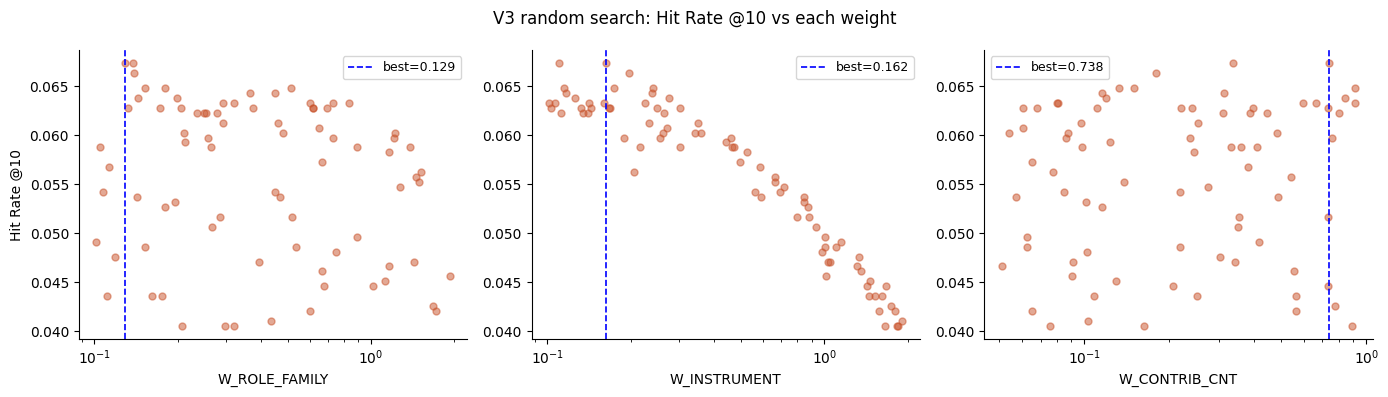

In [16]:
# ── V3 random search scatter — shows which weights matter most ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('V3 random search: Hit Rate @10 vs each weight', fontsize=12)

for ax, col in zip(axes, ['W_ROLE_FAMILY', 'W_INSTRUMENT', 'W_CONTRIB_CNT']):
    ax.scatter(v3_df[col], v3_df['hit_rate'], alpha=0.5, s=25, color='#C8522A')
    ax.axvline(float(v3_best[col]), color='blue', linestyle='--', linewidth=1.2,
               label=f'best={v3_best[col]:.3f}')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Hit Rate @10' if ax == axes[0] else '')
    ax.set_xscale('log')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_v3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
GRID_RF    = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
GRID_INSTR = [0.01, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15]

focused_results = []
total = len(GRID_RF) * len(GRID_INSTR)
print(f'Focused V3 grid: {total} combinations  (W_CONTRIB_CNT=0.0)')
t0 = time.time()

for i, (wrf, wi) in enumerate(itertools.product(GRID_RF, GRID_INSTR), 1):
    weights = {
        'W_COUNTRY':     W_COUNTRY_FIXED,
        'W_TRACK_STATS': W_TRACK_STATS_FIXED,
        'W_ROLE_FAMILY': wrf,
        'W_INSTRUMENT':  wi,
        'W_CONTRIB_CNT': 0.0,
    }
    scores = evaluate_weights(weights)
    focused_results.append({**weights, **scores})

focused_df   = pd.DataFrame(focused_results).sort_values('hit_rate', ascending=False)
focused_best = focused_df.iloc[0]

print(f'Total time: {time.time()-t0:.1f}s')
print(f'\n=== Focused V3 best ===')
print(focused_df.head(10).round(4).to_string(index=False))

print(f'\n=== Updated comparison ===')
print(f'{"Model":<14} {"Hit Rate":>10} {"Precision":>10} {"MRR":>8}')
print('-' * 46)
print(f'{"V1 baseline":<14} {v1_scores["hit_rate"]:>10.4f} '
      f'{v1_scores["precision"]:>10.4f} {v1_scores["mrr"]:>8.4f}')
v2_cmp = evaluate_weights(
    {'W_COUNTRY': W_COUNTRY_FIXED, 'W_TRACK_STATS': W_TRACK_STATS_FIXED}
)
print(f'{"V2 tuned":<14} {v2_cmp["hit_rate"]:>10.4f} '
      f'{v2_cmp["precision"]:>10.4f} {v2_cmp["mrr"]:>8.4f}')
focused_scores = evaluate_weights(
    dict(focused_best[['W_COUNTRY','W_TRACK_STATS',
                        'W_ROLE_FAMILY','W_INSTRUMENT','W_CONTRIB_CNT']])
)
print(f'{"V3 focused":<14} {focused_scores["hit_rate"]:>10.4f} '
      f'{focused_scores["precision"]:>10.4f} {focused_scores["mrr"]:>8.4f}')
print(f'  rf={focused_best["W_ROLE_FAMILY"]:.3f}  '
      f'instr={focused_best["W_INSTRUMENT"]:.3f}  cnt=0.0')

Focused V3 grid: 49 combinations  (W_CONTRIB_CNT=0.0)
Total time: 8870.7s

=== Focused V3 best ===
 W_COUNTRY  W_TRACK_STATS  W_ROLE_FAMILY  W_INSTRUMENT  W_CONTRIB_CNT  hit_rate  precision    mrr  n_eval
       1.0           0.25           0.05          0.03            0.0    0.0704     0.0078 0.0286    1974
       1.0           0.25           0.05          0.01            0.0    0.0699     0.0078 0.0282    1974
       1.0           0.25           0.05          0.05            0.0    0.0694     0.0078 0.0286    1974
       1.0           0.25           0.10          0.01            0.0    0.0694     0.0076 0.0280    1974
       1.0           0.25           0.10          0.05            0.0    0.0694     0.0077 0.0282    1974
       1.0           0.25           0.10          0.08            0.0    0.0694     0.0077 0.0283    1974
       1.0           0.25           0.10          0.03            0.0    0.0689     0.0076 0.0280    1974
       1.0           0.25           0.05          0.1

TypeError: evaluate_weights() takes from 1 to 2 positional arguments but 3 were given

In [18]:
v2_cmp = evaluate_weights(
    {'W_COUNTRY': W_COUNTRY_FIXED, 'W_TRACK_STATS': W_TRACK_STATS_FIXED}
)
print(f'{"V2 tuned":<14} {v2_cmp["hit_rate"]:>10.4f} '
      f'{v2_cmp["precision"]:>10.4f} {v2_cmp["mrr"]:>8.4f}')
focused_scores = evaluate_weights(
    dict(focused_best[['W_COUNTRY','W_TRACK_STATS',
                        'W_ROLE_FAMILY','W_INSTRUMENT','W_CONTRIB_CNT']])
)
print(f'{"V3 focused":<14} {focused_scores["hit_rate"]:>10.4f} '
      f'{focused_scores["precision"]:>10.4f} {focused_scores["mrr"]:>8.4f}')
print(f'  rf={focused_best["W_ROLE_FAMILY"]:.3f}  '
      f'instr={focused_best["W_INSTRUMENT"]:.3f}  cnt=0.0')

V2 tuned           0.0694     0.0076   0.0279
V3 focused         0.0704     0.0078   0.0286
  rf=0.050  instr=0.030  cnt=0.0


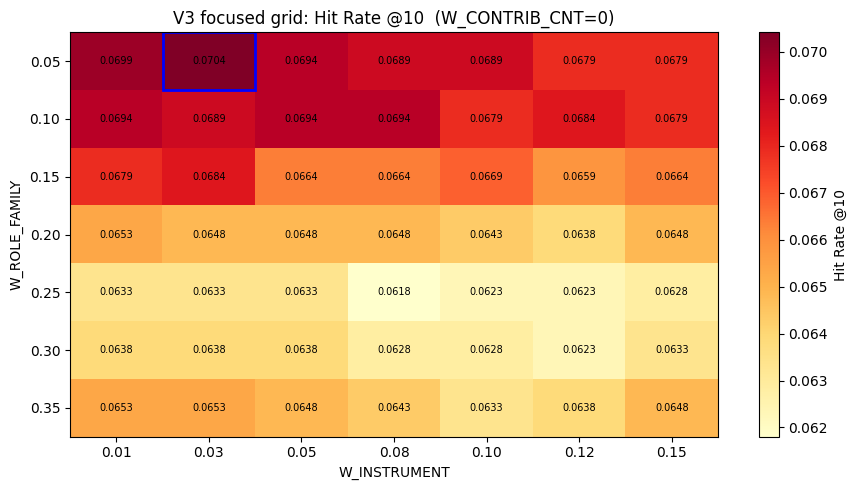

In [19]:
# Heatmap: W_ROLE_FAMILY × W_INSTRUMENT
pivot = focused_df.pivot(
    index='W_ROLE_FAMILY', columns='W_INSTRUMENT', values='hit_rate'
)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Hit Rate @10')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
ax.set_xlabel('W_INSTRUMENT')
ax.set_ylabel('W_ROLE_FAMILY')
ax.set_title('V3 focused grid: Hit Rate @10  (W_CONTRIB_CNT=0)')

for (r, c), val in np.ndenumerate(pivot.values):
    ax.text(c, r, f'{val:.4f}', ha='center', va='center', fontsize=7)

br = list(pivot.index).index(focused_best['W_ROLE_FAMILY'])
bc = list(pivot.columns).index(focused_best['W_INSTRUMENT'])
ax.add_patch(plt.Rectangle(
    (bc-0.5, br-0.5), 1, 1, fill=False, edgecolor='blue', lw=2
))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_v3_focused_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import json

best_weights = {
    "v2": {
        "W_TAGS": 1.0,
        "W_LABELS": 1.0,
        "W_TYPES": 1.0,
        "W_RATINGS": 1.0,
        "W_COUNTRY": 1.0,
        "W_TRACK_STATS": 0.25
    },
    "v3": {
        "W_TAGS": 1.0,
        "W_LABELS": 1.0,
        "W_TYPES": 1.0,
        "W_RATINGS": 1.0,
        "W_COUNTRY": 1.0,
        "W_TRACK_STATS": 0.25,
        "W_ROLE_FAMILY": 0.05,
        "W_INSTRUMENT": 0.03,
        "W_CONTRIB_CNT": 0.0
    }
}

with open('../data/best_weights.json', 'w') as f:
    json.dump(best_weights, f, indent=2)

print('best_weights.json updated with focused V3 values.')

best_weights.json updated with focused V3 values.


In [21]:
# ── Load tuned weights and apply to knn-v2 / knn-v3 ─────────────────────
import json

with open(f'{DATA_DIR}/best_weights.json') as f:
    best_weights = json.load(f)

# ── V2 weights ────────────────────────────────────────────────────────────
W_TAGS        = best_weights['v2']['W_TAGS']
W_LABELS      = best_weights['v2']['W_LABELS']
W_TYPES       = best_weights['v2']['W_TYPES']
W_RATINGS     = best_weights['v2']['W_RATINGS']
W_COUNTRY     = best_weights['v2']['W_COUNTRY']
W_TRACK_STATS = best_weights['v2']['W_TRACK_STATS']

print('V2 weights loaded:')
for k, v in best_weights['v2'].items():
    print(f'  {k:<18} = {v}')

# ── V3 weights (includes all V2 weights + contributor blocks) ─────────────
W_TAGS_V3        = best_weights['v3']['W_TAGS']
W_LABELS_V3      = best_weights['v3']['W_LABELS']
W_TYPES_V3       = best_weights['v3']['W_TYPES']
W_RATINGS_V3     = best_weights['v3']['W_RATINGS']
W_COUNTRY_V3     = best_weights['v3']['W_COUNTRY']
W_TRACK_STATS_V3 = best_weights['v3']['W_TRACK_STATS']
W_ROLE_FAMILY    = best_weights['v3']['W_ROLE_FAMILY']
W_INSTRUMENT     = best_weights['v3']['W_INSTRUMENT']
W_CONTRIB_CNT    = best_weights['v3']['W_CONTRIB_CNT']

print('\nV3 weights loaded:')
for k, v in best_weights['v3'].items():
    print(f'  {k:<18} = {v}')

# ── Rebuild and save both models with tuned weights ───────────────────────
import os, joblib
from scipy.sparse import hstack, save_npz
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

def build_and_save(weights, model_dir):
    os.makedirs(f'{DATA_DIR}/{model_dir}', exist_ok=True)

    blocks = [
        X_tags        * weights.get('W_TAGS',        1.0),
        X_labels      * weights.get('W_LABELS',      1.0),
        X_types       * weights.get('W_TYPES',       1.0),
        X_ratings     * weights.get('W_RATINGS',     1.0),
        X_country     * weights.get('W_COUNTRY',     0.0),
        X_track_stats * weights.get('W_TRACK_STATS', 0.0),
    ]
    if weights.get('W_ROLE_FAMILY', 0.0) > 0:
        blocks += [
            X_role_family * weights.get('W_ROLE_FAMILY', 0.0),
            X_instrument  * weights.get('W_INSTRUMENT',  0.0),
            X_contrib_cnt * weights.get('W_CONTRIB_CNT', 0.0),
        ]

    X_full      = hstack(blocks).tocsr()
    col_nnz     = np.diff(X_full.tocsc().indptr)
    row_lengths = np.diff(X_full.indptr)
    has_feat    = row_lengths > 0
    nonempty    = np.where(has_feat)[0]
    col_vals    = col_nnz[X_full.indices]
    max_col     = np.zeros(X_full.shape[0], dtype=col_nnz.dtype)
    max_col[nonempty] = np.maximum.reduceat(col_vals, X_full.indptr[nonempty])
    safe_thresh = int(max_col[has_feat].min())
    X_pruned    = X_full[:, col_nnz >= safe_thresh]

    X_ann  = X_pruned[has_feat].copy()
    ids_ann = np.array(album_id_order)[has_feat]
    np.nan_to_num(X_ann.data, nan=0.0, copy=False)
    X_ann.eliminate_zeros()
    X_norm = normalize(X_ann, norm='l2')

    model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
    model.fit(X_norm)

    suffix = model_dir.replace('model', '').replace('_', '') or ''
    joblib.dump(model,  f'{DATA_DIR}/{model_dir}/knn_model{suffix}.joblib')
    save_npz(f'{DATA_DIR}/{model_dir}/X_knn_norm{suffix}.npz', X_norm)
    np.save(f'{DATA_DIR}/{model_dir}/album_ids_annotated{suffix}.npy', ids_ann)
    np.save(f'{DATA_DIR}/{model_dir}/has_features{suffix}.npy', has_feat)

    print(f'Saved to {model_dir}/  '
          f'({X_norm.shape[0]:,} albums x {X_norm.shape[1]:,} features)')


print('\nRebuilding V2 with tuned weights...')
build_and_save(best_weights['v2'], 'model_v2')

print('Rebuilding V3 with tuned weights...')
build_and_save(best_weights['v3'], 'model_v3')

print('\nDone. Models saved and ready for use in app_sql_v3.py')

V2 weights loaded:
  W_TAGS             = 1.0
  W_LABELS           = 1.0
  W_TYPES            = 1.0
  W_RATINGS          = 1.0
  W_COUNTRY          = 1.0
  W_TRACK_STATS      = 0.25

V3 weights loaded:
  W_TAGS             = 1.0
  W_LABELS           = 0.32472055144502865
  W_TYPES            = 3.5067764992972172
  W_RATINGS          = 0.1
  W_COUNTRY          = 1.0
  W_TRACK_STATS      = 0.25
  W_ROLE_FAMILY      = 0.05
  W_INSTRUMENT       = 0.03
  W_CONTRIB_CNT      = 0.0

Rebuilding V2 with tuned weights...
Saved to model_v2/  (1,008,102 albums x 5,854 features)
Rebuilding V3 with tuned weights...
Saved to model_v3/  (1,008,102 albums x 6,459 features)

Done. Models saved and ready for use in app_sql_v3.py
